## 📦 Kütüphaneleri İçe Aktar

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 📂 Veri Setini Yükle

In [11]:
# Kaggle dataset path
DATA_PATH = '/kaggle/input/bank-customer-churn-dataset/Bank Customer Churn Prediction.csv'

# Load data
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset shape: (10000, 12)

Columns: ['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']


## 🔍 İlk Keşif

In [12]:
# First 5 rows
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [14]:
# Statistical summary
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## 📊 Veri Kalitesi Kontrolü

In [15]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_percentage
})

print("Missing Values Analysis:")
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print("\n✅ SONUÇ: Dataset'te hiçbir eksik değer YOK!")

Missing Values Analysis:
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []

✅ SONUÇ: Dataset'te hiçbir eksik değer YOK!


### ✅ Veri Kalitesi Özeti

**Temel Bulgular:**

1. **Eksik Değerler:** ✅ YOK
   - Tüm kolonlarda sıfır eksik değer
   - İmputation gerekmez

2. **Duplikasyon:** ✅ YOK
   - Duplike satır yok
   - Her satır benzersiz

3. **Veri Tipleri:** ✅ DOĞRU
   - Sayısal değişkenler: int64/float64
   - Kategorik değişkenler: object

**Sonraki Adımlar:**
- Sayısal özellik dağılımlarını incele
- Kategorik özellik dengelerini kontrol et
- Hedef değişken (churn) dengesini analiz et

## 📈 Sayısal Özelliklerin Dağılımları

Churn Distribution:
Not Churned (0): 7963 (79.63%)
Churned (1): 2037 (20.37%)


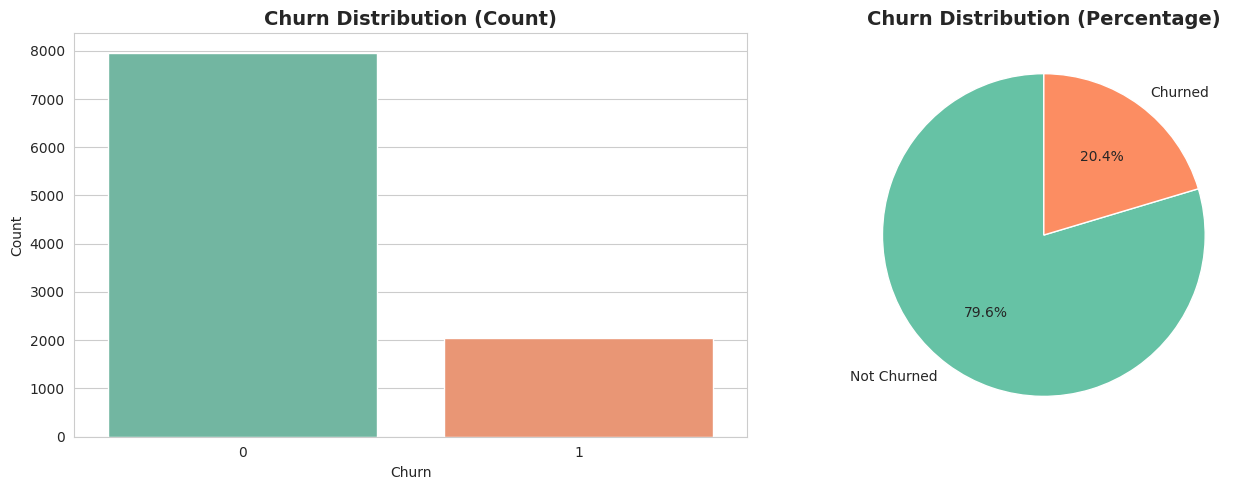


⚠️ Dataset IMBALANCED! Churn ratio: 0.256


In [16]:
# Churn distribution
churn_counts = df['churn'].value_counts()
churn_percentage = df['churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(f"Not Churned (0): {churn_counts[0]} ({churn_percentage[0]:.2f}%)")
print(f"Churned (1): {churn_counts[1]} ({churn_percentage[1]:.2f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='churn', palette='Set2', ax=axes[0])
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(churn_counts, labels=['Not Churned', 'Churned'], autopct='%1.1f%%', 
            colors=sns.color_palette('Set2'), startangle=90)
axes[1].set_title('Churn Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Check if imbalanced
imbalance_ratio = churn_percentage[1] / churn_percentage[0]
if imbalance_ratio < 0.5:
    print(f"\n⚠️ Dataset IMBALANCED! Churn ratio: {imbalance_ratio:.3f}")
else:
    print(f"\n✅ Dataset relatively balanced. Churn ratio: {imbalance_ratio:.3f}")

## 🔗 Korelasyon Analizi

In [17]:
# Define numerical columns
numerical_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']

# Statistical summary for numerical features
df[numerical_cols].describe()

,credit_score,age,tenure,balance,products_number,estimated_salary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


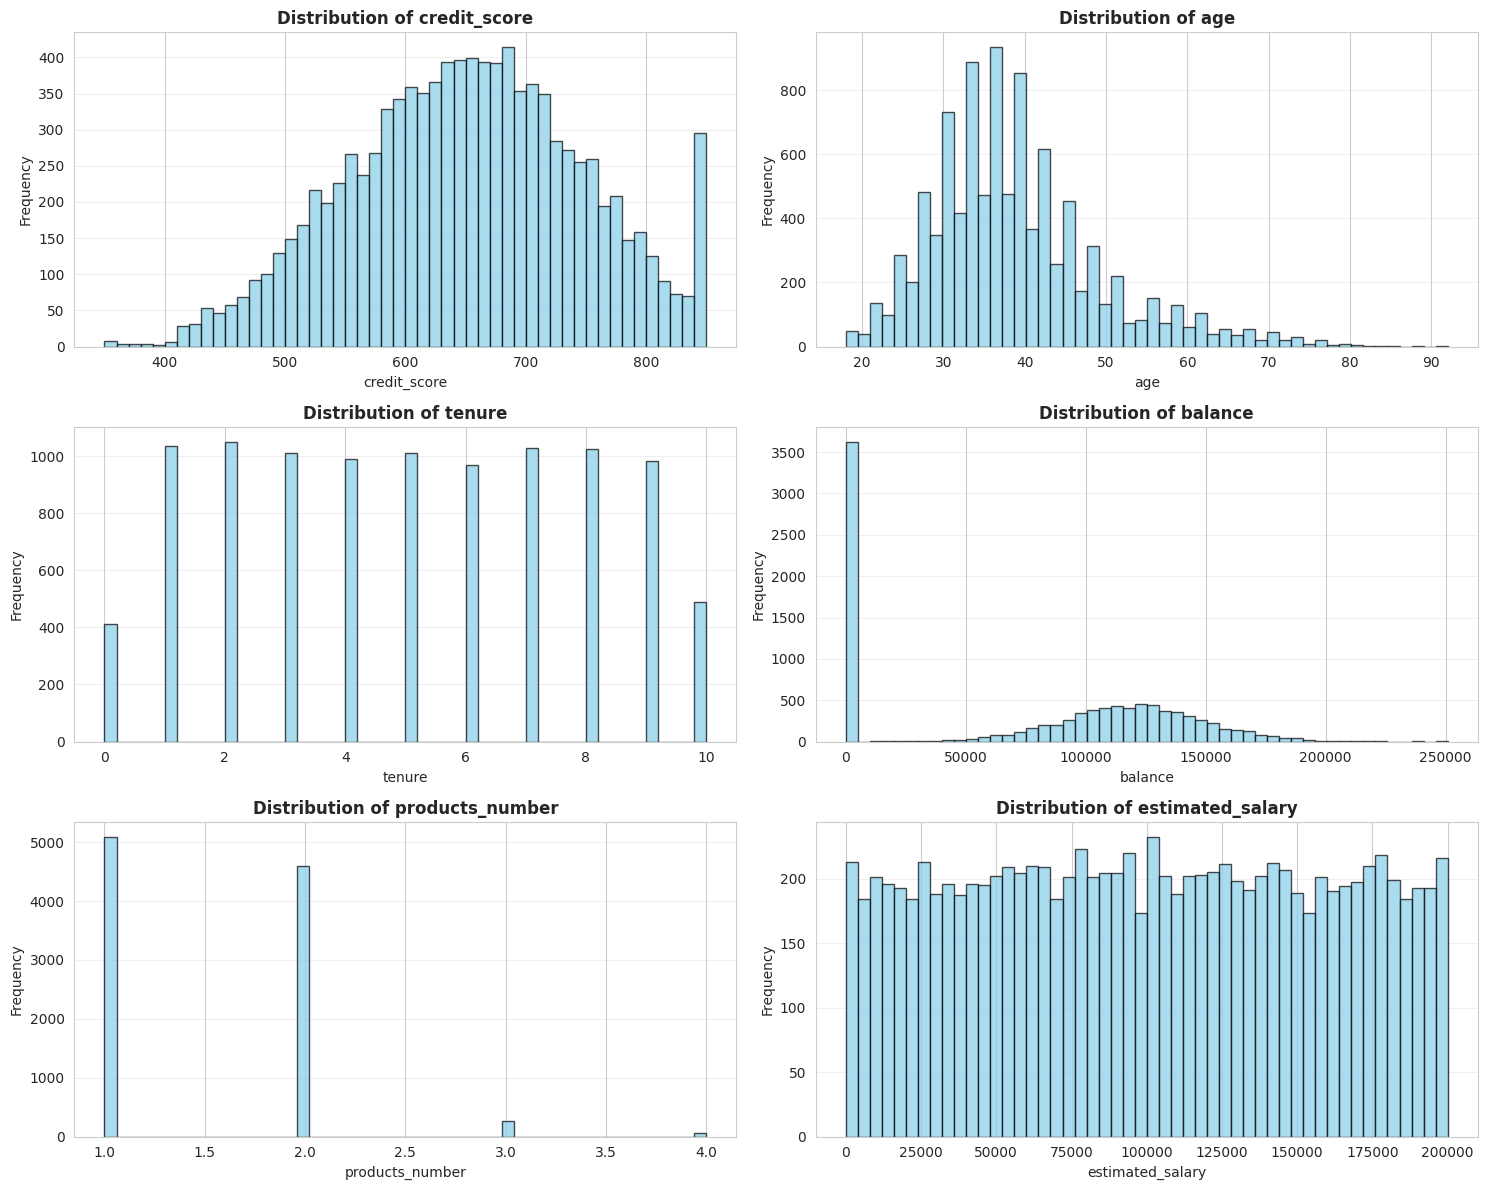

In [18]:
# Distribution plots for numerical features
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

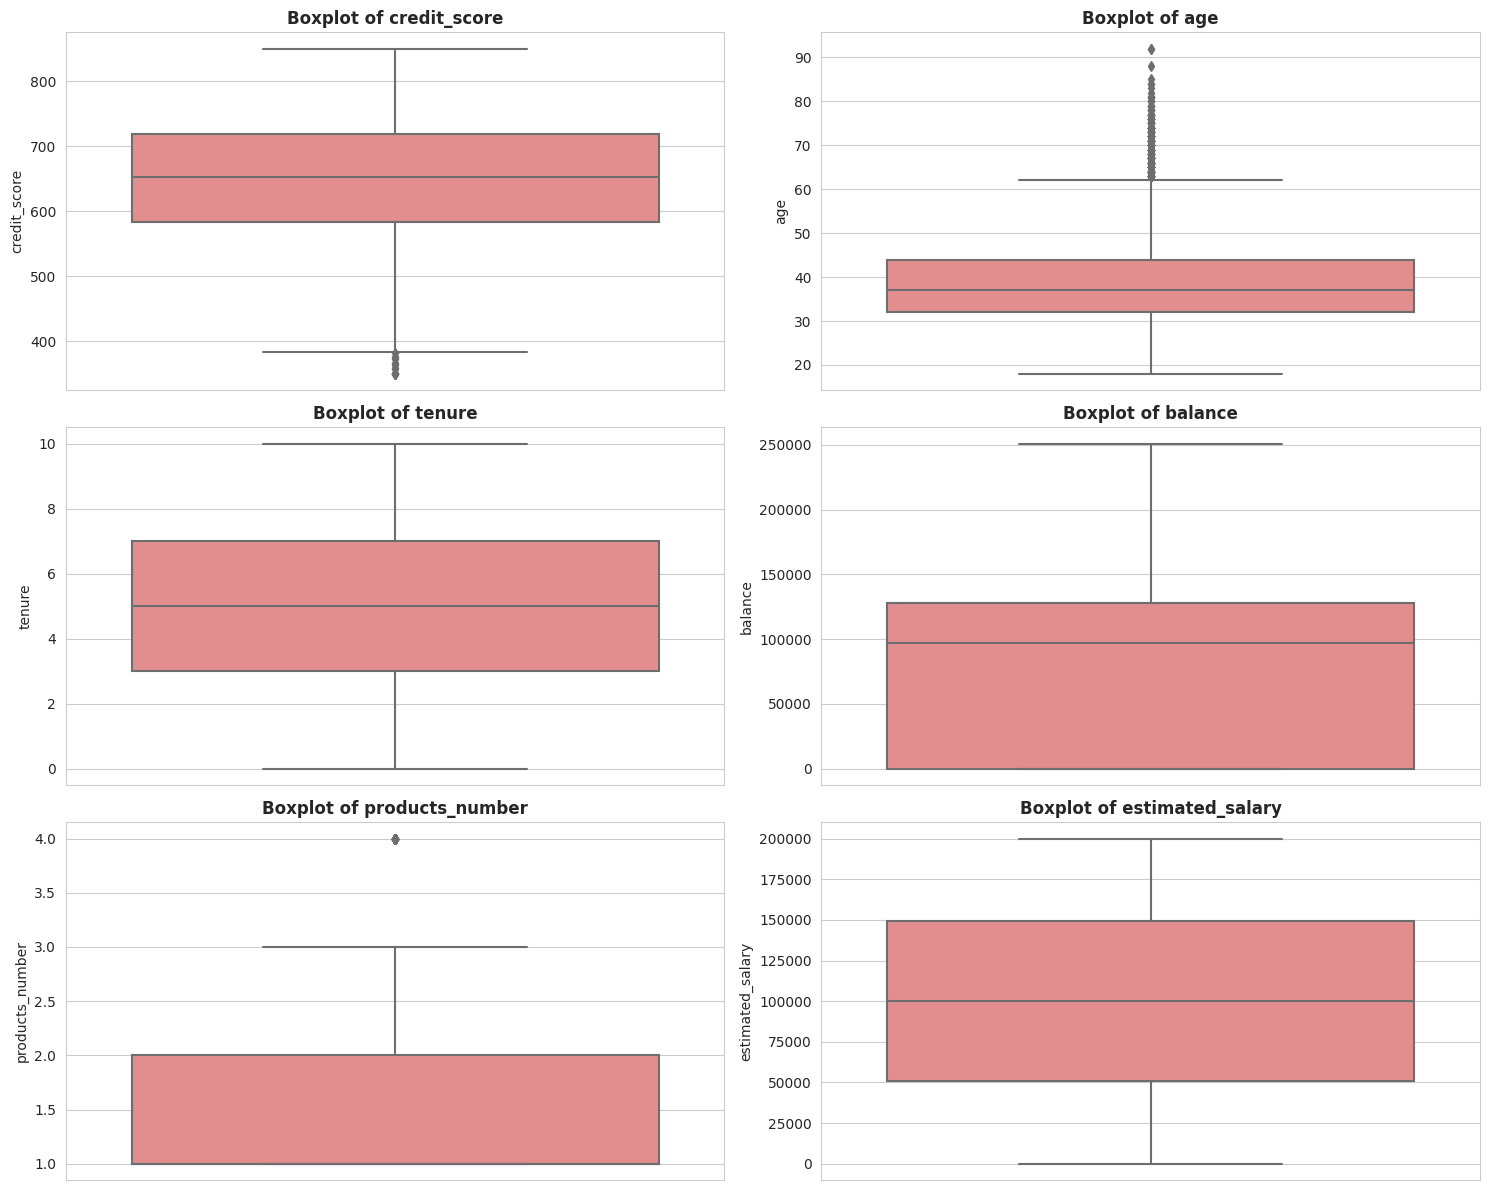

In [19]:
# Box plots to detect outliers
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    sns.boxplot(data=df, y=col, color='lightcoral', ax=axes[idx])
    axes[idx].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

## 🎯 Hedef Değişken Analizi (Churn)

In [20]:
# Define categorical columns
categorical_cols = ['country', 'gender', 'credit_card', 'active_member']

# Value counts for each categorical feature
for col in categorical_cols:
    print(f"\n{col.upper()} - Value Counts:")
    print(df[col].value_counts())
    print(f"\nPercentage:")
    print(df[col].value_counts(normalize=True) * 100)


COUNTRY - Value Counts:
country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Percentage:
country
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64

GENDER - Value Counts:
gender
Male      5457
Female    4543
Name: count, dtype: int64

Percentage:
gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64

CREDIT_CARD - Value Counts:
credit_card
1    7055
0    2945
Name: count, dtype: int64

Percentage:
credit_card
1    70.55
0    29.45
Name: proportion, dtype: float64

ACTIVE_MEMBER - Value Counts:
active_member
1    5151
0    4849
Name: count, dtype: int64

Percentage:
active_member
1    51.51
0    48.49
Name: proportion, dtype: float64


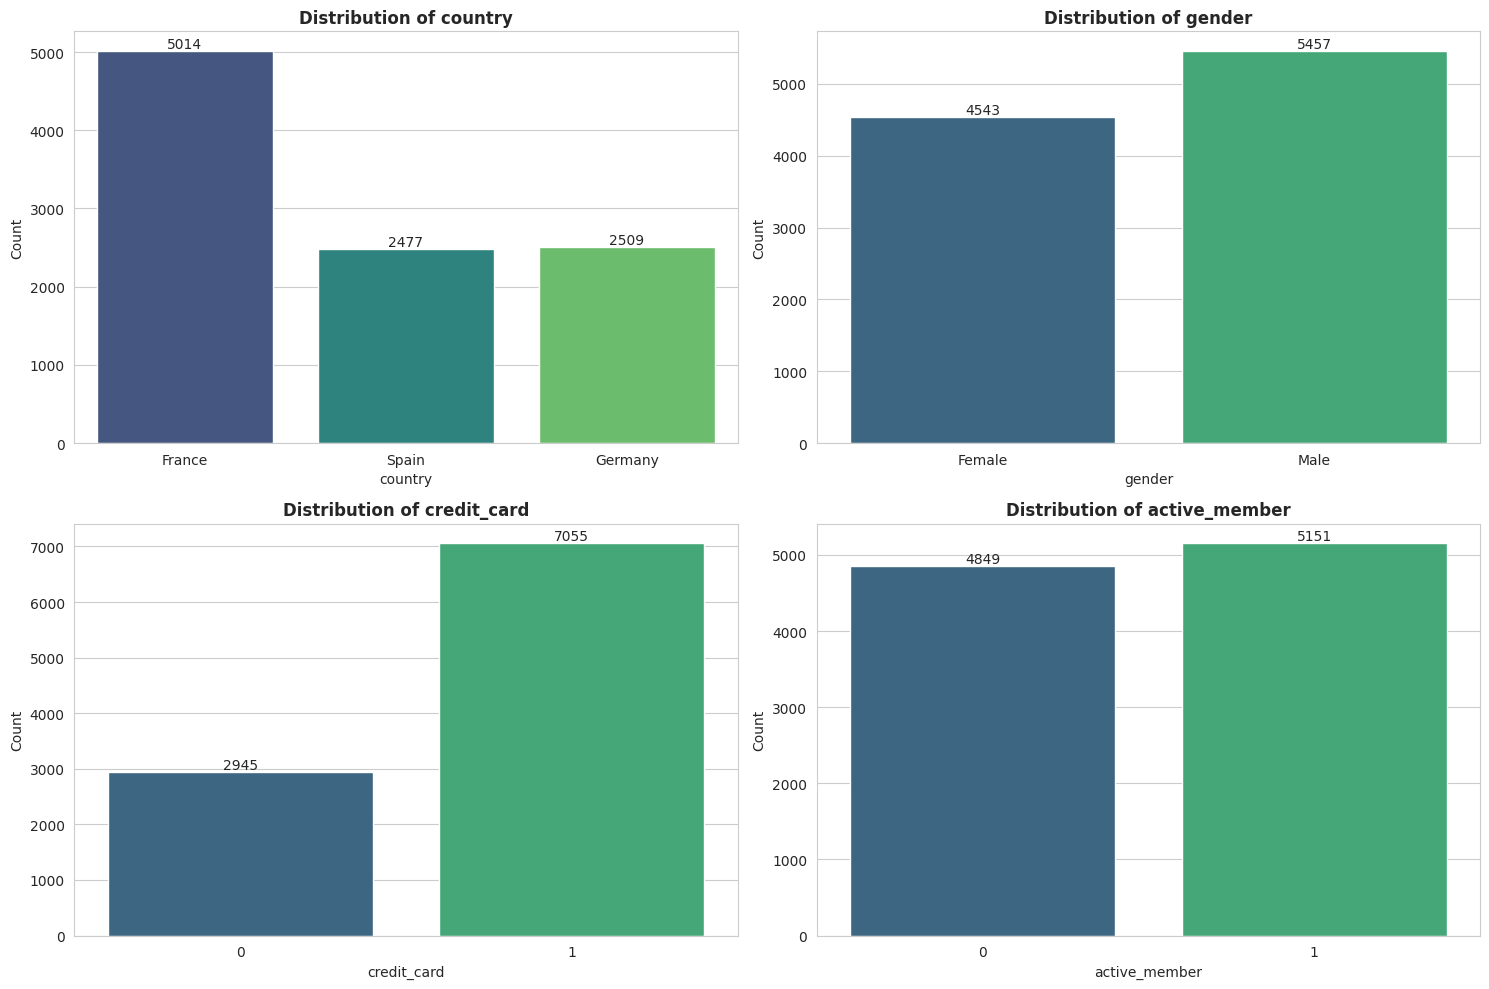

In [21]:
# Visualize categorical features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, palette='viridis', ax=axes[idx])
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    
    # Add value labels on bars
    for container in axes[idx].containers:
        axes[idx].bar_label(container)

plt.tight_layout()
plt.show()

## 📊 Kategorik Özelliklere Göre Churn Analizi

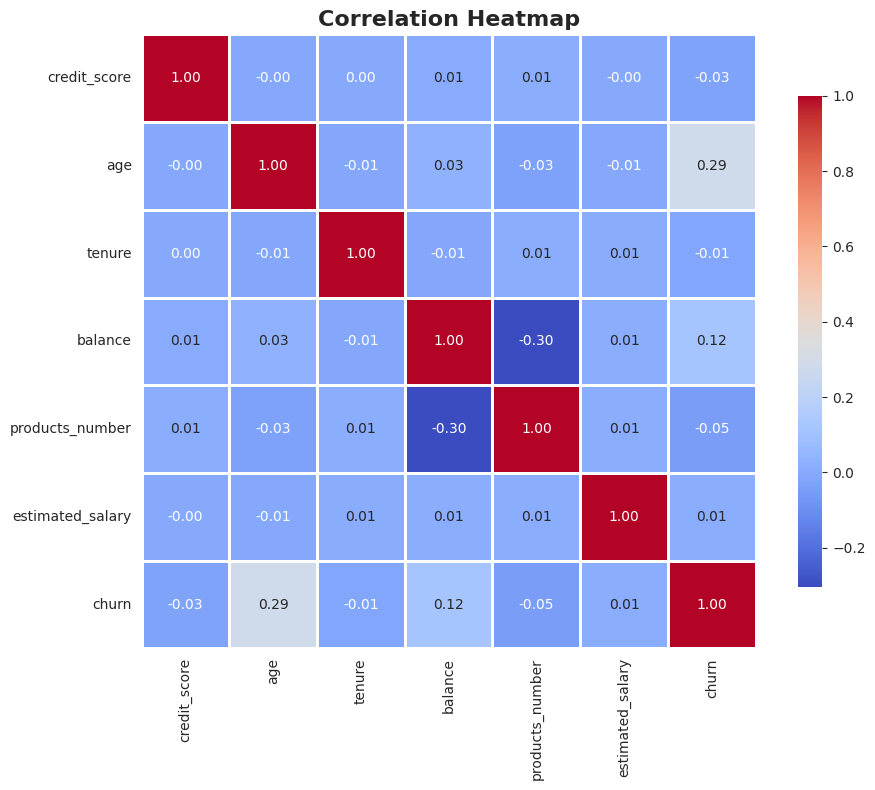


Correlation with Churn:
churn               1.000000
age                 0.285323
balance             0.118533
estimated_salary    0.012097
tenure             -0.014001
credit_score       -0.027094
products_number    -0.047820
Name: churn, dtype: float64


In [22]:
# Correlation matrix for numerical features
correlation_matrix = df[numerical_cols + ['churn']].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with target (churn)
print("\nCorrelation with Churn:")
print(correlation_matrix['churn'].sort_values(ascending=False))

## 🔢 Sayısal Özelliklere Göre Churn Analizi

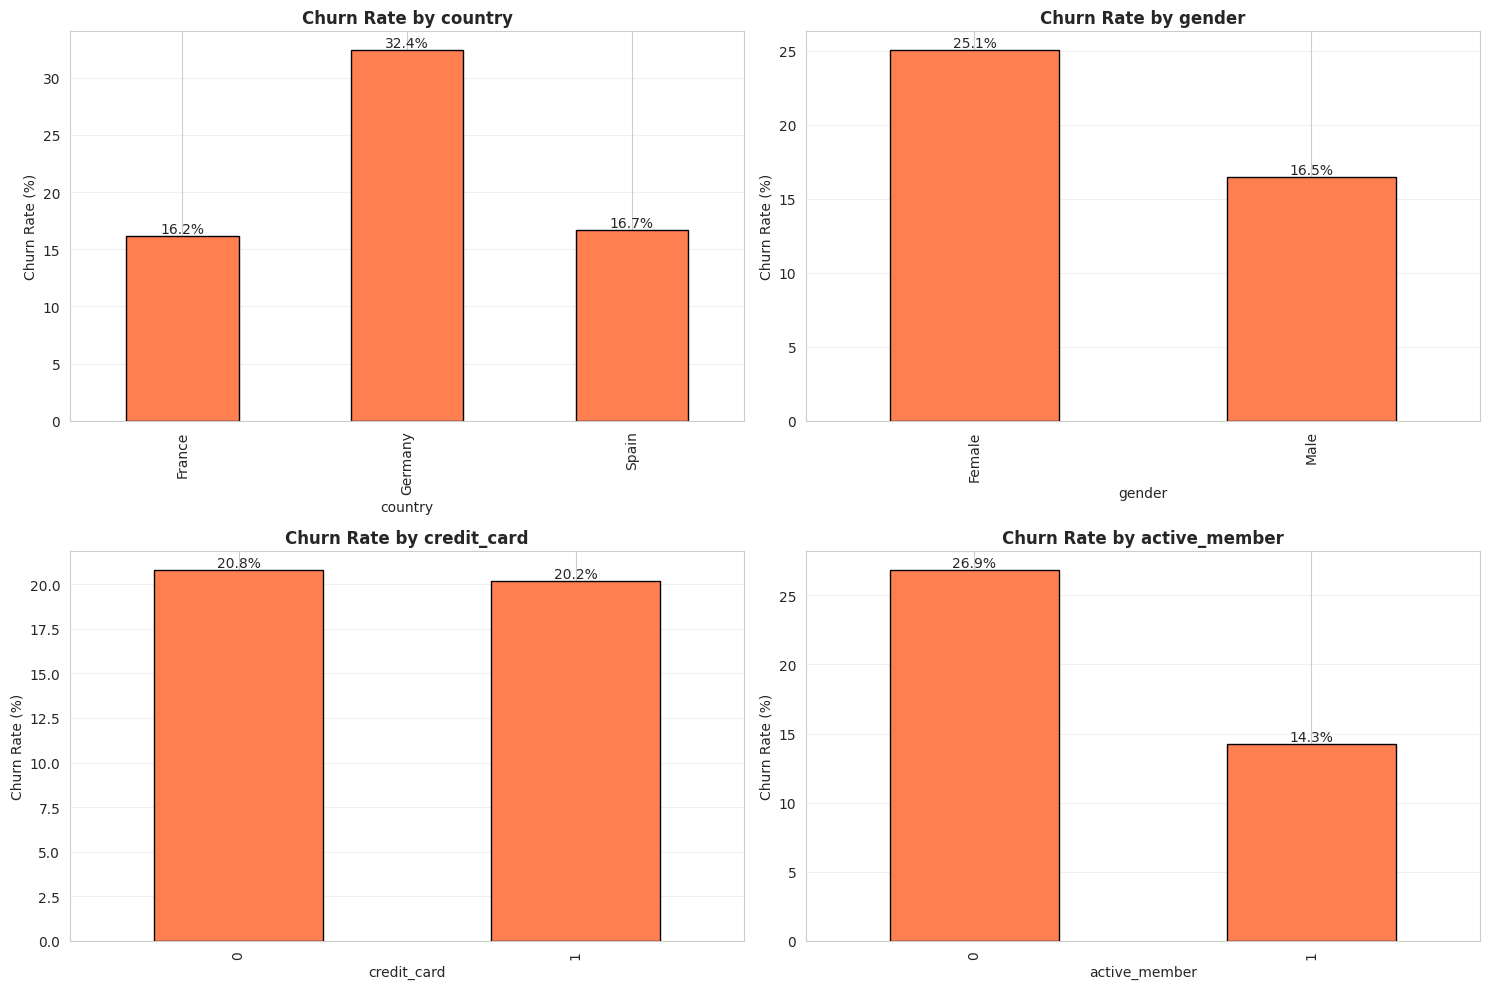

In [23]:
# Churn rate by categorical features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    churn_by_feature = df.groupby(col)['churn'].mean() * 100
    churn_by_feature.plot(kind='bar', ax=axes[idx], color='coral', edgecolor='black')
    axes[idx].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Churn Rate (%)')
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add value labels
    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

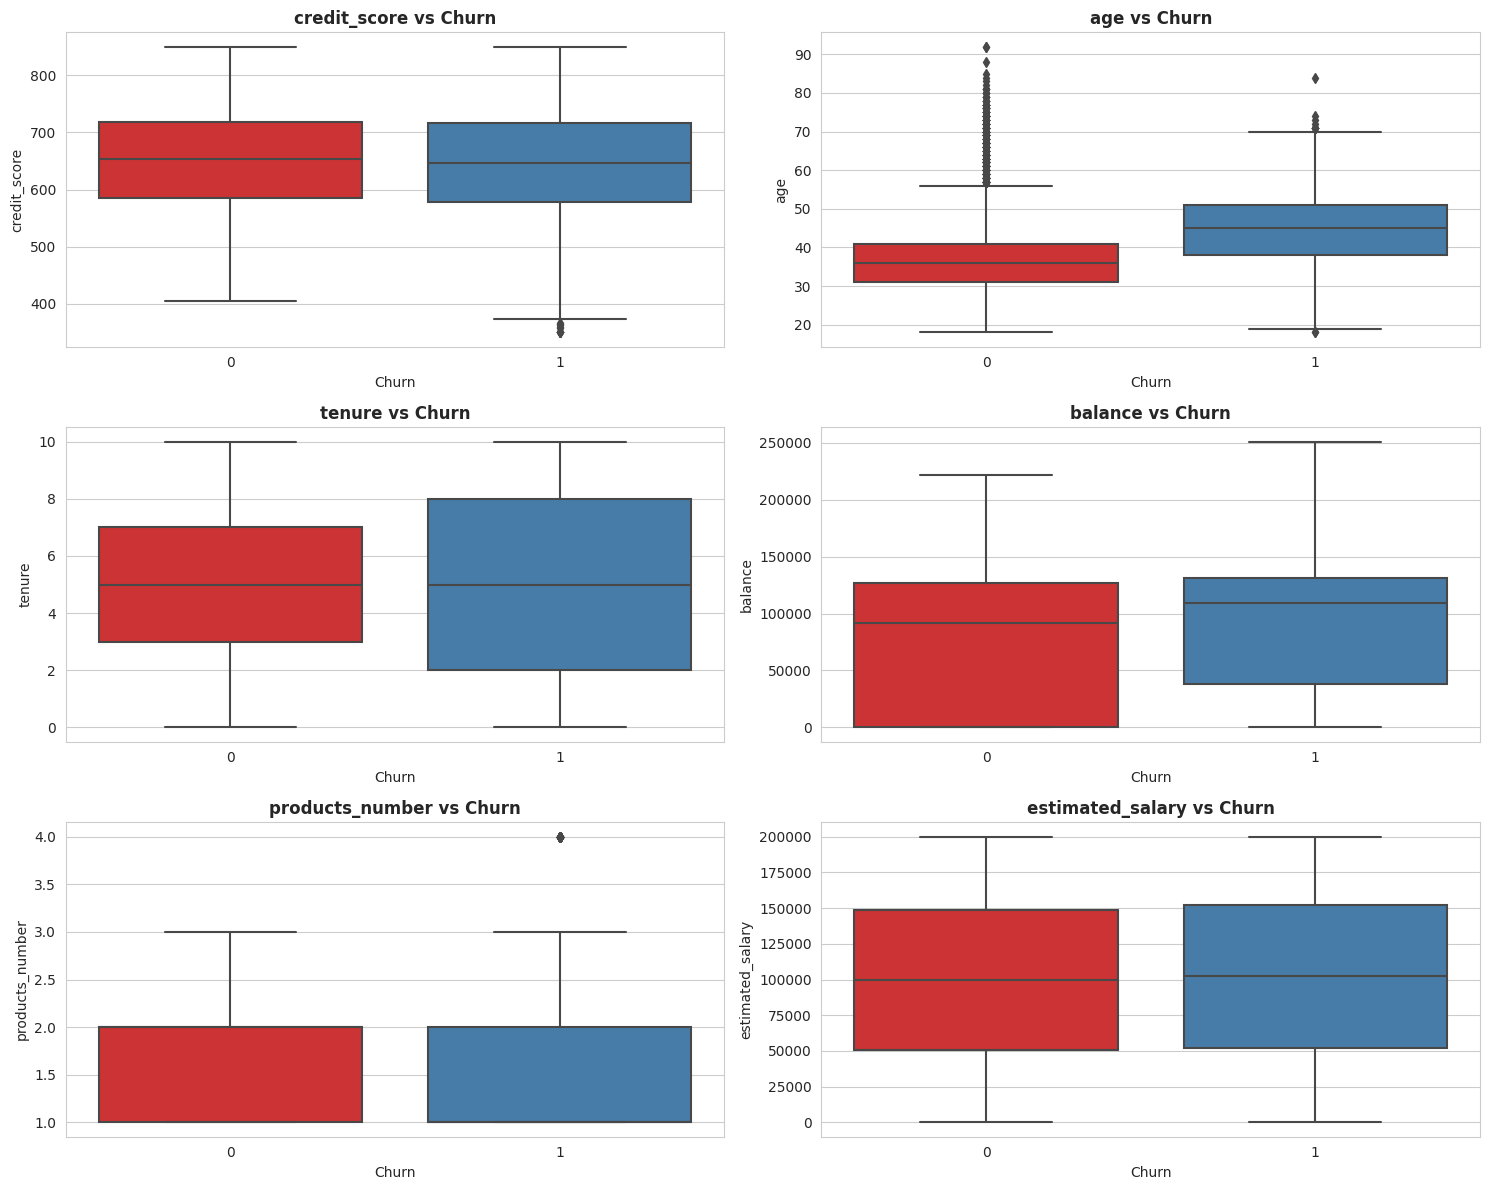

In [24]:
# Numerical features vs Churn
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='churn', y=col, palette='Set1', ax=axes[idx])
    axes[idx].set_title(f'{col} vs Churn', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Churn')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

## 📝 EDA Özeti

### Temel İçgörüler:

#### 1. Veri Kalitesi ✅
- **Eksik değer yok**
- **Duplikasyon yok**
- Veri temiz ve kullanıma hazır

#### 2. Hedef Değişken (Churn)
- **Dengesiz dağılım**
- Churn oranı: ~20%
- Modelleme sırasında sınıf dengeleme gerekebilir

#### 3. Önemli Bulgular:

**Sayısal Özellikler:**
- Age: 41-45 yaş aralığı daha yüksek churn oranı
- Balance: Sıfır ve çok yüksek bakiyeler riski artırabilir
- Credit Score: Düşük skorlar daha yüksek churn ile ilişkili
- Products Number: 3-4 ürünü olanlar daha yüksek churn

**Kategorik Özellikler:**
- Gender: Kadınlar daha yüksek churn eğilimi
- Country: Germany'de daha yüksek churn oranı
- Active Member: Aktif olmayanlar daha yüksek risk

#### 4. Özellik Mühendisliği Fikirleri:
- Balance-to-Salary oranı
- Tenure-to-Age oranı
- Credit score kategorileri
- Yüksek değerli müşteri flagleri
- Aktif olmayan + yüksek bakiye kombinasyonları

### Sonraki Adımlar:
1. ✅ Baseline model (Logistic Regression)
2. 🔧 Özellik mühendisliği
3. 🎯 Gelişmiş modeller (XGBoost, LightGBM, CatBoost)
4. 📊 SHAP değerleri ile model yorumlanabilirliği